In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [4]:
results_mapping = {
    "RTX 4090": "results/metrics_RTX-4090_r3.csv",
    "RTX A6000": "results/metrics_RTX-A6000_r3.csv",
    "M3 Max": "results/metrics_M3-Max.csv",
    "OpenAI": "results/metrics_OpenAI.csv",
    "Anthropic": "results/metrics_Anthropic.csv",
}

In [5]:
# Custom order for models by size and platform
model_order = {
    "qwen2.5:3b": 0.5,
    "qwen2.5:7b": 1,
    "qwen2.5:14b": 2.5,
    "qwen2.5:32b": 3,
    "qwen2.5:72b": 5,
    "functionary-small": 6,
    "functionary-medium": 7,
    "gpt-4o-mini": 99,
    "gpt-4o": 100,
    "gpt-4.1-nano": 101,
    "gpt-4.1-mini": 102,
    "gpt-4.1": 103,
    # "o4-mini": 104,
    "claude-3-5-sonnet": 110,
    "claude-3-7-sonnet": 120,
}

In [6]:
import pandas as pd

def get_metrics_df(type: str = "overall") -> pd.DataFrame:
    metrics_df = pd.DataFrame()
    for platform, results in results_mapping.items():
        results_df = pd.read_csv(results)
        results_df = results_df[results_df["type"] == type].copy()
        results_df["platform"] = platform
        results_df["model"] = results_df["model"].str.replace("qwen2.5_", "qwen2.5:")
        metrics_df = pd.concat([metrics_df, results_df], ignore_index=True)

    metrics_df = metrics_df[metrics_df["model"].isin(model_order.keys())].copy().reset_index(drop=True)
    return metrics_df

metrics_df = get_metrics_df()
metrics_df

,platform,model,type,task_completion_rate,task_success_rate,total_execution_time,mean_execution_time,std_execution_time,mean_process_steps,std_process_steps,...,DB_UPDATE_TOOL_ARGS_MISMATCH,DB_QUERY_TOOL_NOT_INITIALIZED,DB_QUERY_TOOL_ARGS_MISMATCH,DB_UPDATE_TOOL_ERROR,OCR_TOOL_RESULT_MISMATCH,OCR_TOOL_ARGS_MISMATCH,mean_ocr_bert_f1,std_ocr_bert_f1,OCR_TOOL_NOT_INITIALIZED,OCR_TOOL_ERROR
0,RTX 4090,qwen2.5:3b,overall,1,0.131313,21695.334635,10.957240,31.096119,17.242424,12.511735,...,36.0,21.0,15.0,3.0,1.0,1.0,NaN,NaN,NaN,NaN
1,RTX 4090,qwen2.5:7b,overall,1,0.493434,24863.201408,12.557172,14.711192,16.868182,20.287531,...,1.0,370.0,8.0,NaN,NaN,NaN,NaN,NaN,606.0,NaN
2,RTX 4090,qwen2.5:14b,overall,1,0.973737,24793.655764,12.522048,11.297970,8.610606,2.103773,...,1.0,29.0,2.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,RTX A6000,qwen2.5:3b,overall,1,0.139394,15993.659731,8.077606,19.006940,18.751010,14.731147,...,35.0,7.0,24.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN
4,RTX A6000,qwen2.5:7b,overall,1,0.572727,19611.060440,9.904576,10.236681,20.687374,21.975266,...,3.0,415.0,21.0,1.0,NaN,NaN,NaN,NaN,369.0,NaN
5,RTX A6000,functionary-small,overall,1,0.074747,7956.671884,4.018521,21.637443,5.595960,3.656055,...,3.0,1379.0,12.0,NaN,NaN,133.0,NaN,NaN,NaN,NaN
6,RTX A6000,qwen2.5:14b,overall,1,0.966162,14455.940966,7.300980,7.959315,8.620202,2.234191,...,1.0,46.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,RTX A6000,qwen2.5:32b,overall,1,1.000000,27469.971908,13.873723,16.945396,8.500000,0.500126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,RTX A6000,functionary-medium,overall,1,0.531818,60963.819832,30.789808,242.603004,7.806566,2.839741,...,5.0,454.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,RTX A6000,qwen2.5:72b,overall,1,0.951010,77727.089742,39.256106,24.812186,8.735859,4.228136,...,NaN,85.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
metrics_df.to_csv("results/metrics.csv", index=False)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_df(metrics_df: pd.DataFrame, title="Performance Metrics of Models on Different Platforms - All Tasks") -> None:
    # df = metrics_df[:-2].copy()
    df = metrics_df.copy()

    platform_order = {key: i for i, key in enumerate(results_mapping.keys())}
    print("platform order:", platform_order)
    df["model_order"] = df["model"].map(model_order)
    df["platform_order"] = df["model"].map(platform_order)
    df["combined"] = df["model"] + "\n(Platform: " + df["platform"] + ")"

    df["combined"] = df.apply(
        lambda x: x["combined"]
        + f"\n[Steps: {x['mean_process_steps']:.2f} ± {x['std_process_steps']:.2f}]",
        axis=1,
    )
    df = df.sort_values(by=["model_order", "platform_order"], ascending=[True, True])

    # Setting up data for plotting
    x_labels = df["combined"]
    x_pos = np.arange(len(x_labels))

    # Adding horizontal dashed lines for GPT-4o and GPT-4o-mini
    fig, ax = plt.subplots(2, 1, figsize=(15, 6))

    # First subplot: Success Rate
    ax[0].bar(
        x_pos, df["task_success_rate"] * 100, label="Models"
    )  # Convert to percentage
    ax[0].set_title("(a) Success Rate (%)")
    ax[0].set_xticks(x_pos)
    ax[0].set_xticklabels([])
    ax[0].set_ylabel("Success Rate (%)")
    ax[0].set_ylim(0, 115)
    for i, v in enumerate(df["task_success_rate"] * 100):
        ax[0].text(i, v + 1, f"{v:.1f}", ha="center", fontsize=13)

    # Adding horizontal dashed lines for GPT-4o and GPT-4o-mini
    # claude_3_7_success_rate = (
    #     metrics_df[metrics_df["model"] == "claude-3-7-sonnet"].iloc[0]["task_success_rate"] * 100
    # )
    # claude_3_5_success_rate = (
    #     metrics_df[metrics_df["model"] == "claude-3-5-sonnet"].iloc[0]["task_success_rate"] * 100
    # )
    # ax[0].axhline(
    #     y=claude_3_7_success_rate,
    #     color="red",
    #     linestyle="--",
    #     label=f"Claude 3.7 Sonnet ({claude_3_7_success_rate:.2f}%)",
    # )
    # ax[0].axhline(
    #     y=claude_3_5_success_rate,
    #     color="blue",
    #     linestyle="--",
    #     label=f"Claude 3.5 Sonnet ({claude_3_5_success_rate:.2f}%)",
    # )

    # move legend down a bit
    ax[0].legend(loc="upper left", bbox_to_anchor=(0, 0.95))
    # ax[0].legend(loc="upper left")

    # Second subplot: Mean Execution Time
    ax[1].bar(x_pos, df["mean_execution_time"], label="Models")
    ax[1].set_title("(b) Mean Execution Time (s)")
    ax[1].set_xticks(x_pos)
    ax[1].set_xticklabels([])
    ax[1].set_ylabel("Mean Execution Time (s)")
    for i, v in enumerate(df["mean_execution_time"]):
        ax[1].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=13)
    # Adding horizontal dashed lines for GPT-4o and GPT-4o-mini
    # claude_3_7_execution_time = metrics_df[metrics_df["model"] == "claude-3-7-sonnet"].iloc[0][
    #     "mean_execution_time"
    # ]
    # claude_3_5_execution_time = metrics_df[metrics_df["model"] == "claude-3-5-sonnet"].iloc[0][
    #     "mean_execution_time"
    # ]
    # ax[1].axhline(
    #     y=claude_3_7_execution_time,
    #     color="red",
    #     linestyle="--",
    #     label=f"Claude 3.7 Sonnet ({claude_3_7_execution_time:.1f}s)",
    # )
    # ax[1].axhline(
    #     y=claude_3_5_execution_time,
    #     color="blue",
    #     linestyle="--",
    #     label=f"Claude 3.5 Sonnet ({claude_3_5_execution_time:.1f}s)",
    # )
    ax[1].legend(loc="upper left")
    ax[1].set_ylim(0, 109)
    ax[1].set_xticks(x_pos)
    ax[1].set_xticklabels(x_labels, rotation=60, ha="center", fontsize=9)

    plt.suptitle(title, fontsize=16)

    # Layout adjustments
    plt.tight_layout()
    plt.show()

platform order: {'RTX 4090': 0, 'RTX A6000': 1, 'M3 Max': 2, 'OpenAI': 3, 'Anthropic': 4}


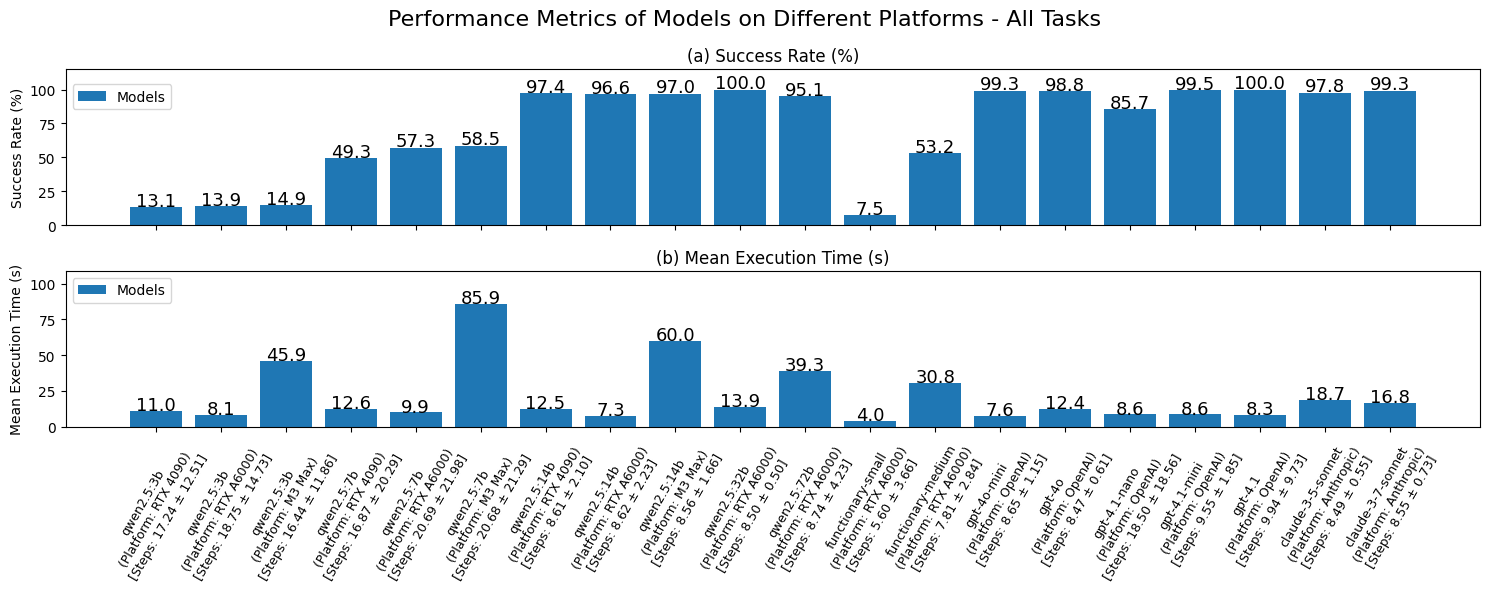

In [9]:
plot_metrics_df(metrics_df)

platform order: {'RTX 4090': 0, 'RTX A6000': 1, 'M3 Max': 2, 'OpenAI': 3, 'Anthropic': 4}


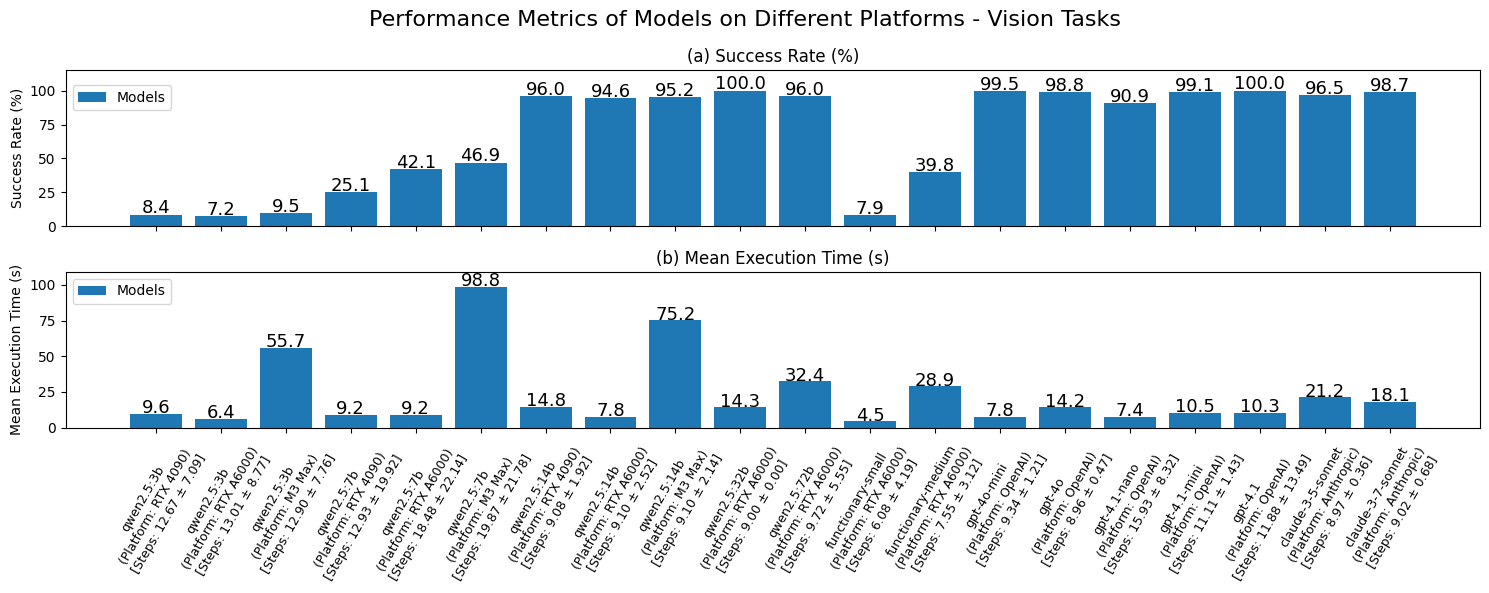

In [10]:
metrics_df = get_metrics_df(type="vision")
plot_metrics_df(metrics_df, title="Performance Metrics of Models on Different Platforms - Vision Tasks")
metrics_df.to_csv("results/metrics-vision.csv", index=False)

platform order: {'RTX 4090': 0, 'RTX A6000': 1, 'M3 Max': 2, 'OpenAI': 3, 'Anthropic': 4}


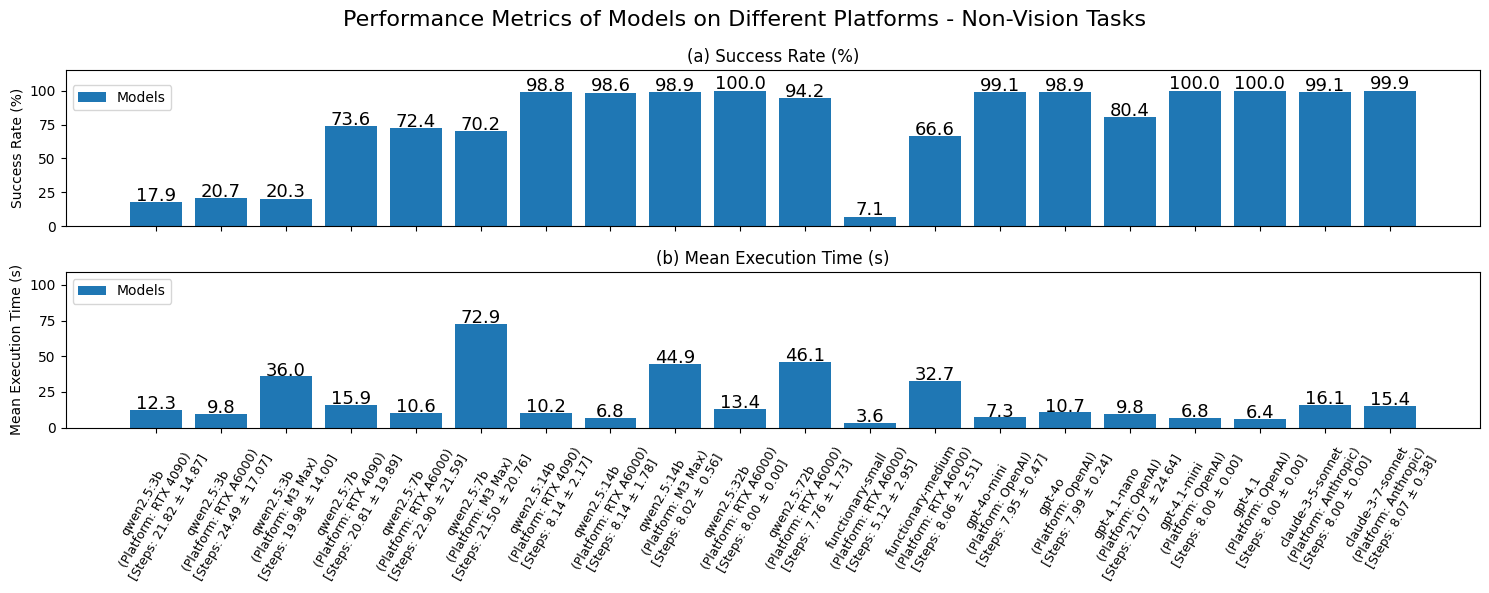

In [11]:
metrics_df = get_metrics_df(type="non-vision")
plot_metrics_df(metrics_df, title="Performance Metrics of Models on Different Platforms - Non-Vision Tasks")
metrics_df.to_csv("results/metrics-non-vision.csv", index=False)

In [12]:
df_error_columns = metrics_df.columns[metrics_df.columns.str.contains("TOOL")].tolist()
df_error_columns.sort()
df_error_columns

['DB_QUERY_TOOL_ARGS_MISMATCH',
 'DB_QUERY_TOOL_NOT_INITIALIZED',
 'DB_UPDATE_TOOL_ARGS_MISMATCH',
 'DB_UPDATE_TOOL_ERROR',
 'DB_UPDATE_TOOL_NOT_INITIALIZED',
 'OCR_TOOL_ARGS_MISMATCH',
 'OCR_TOOL_ERROR',
 'OCR_TOOL_NOT_INITIALIZED',
 'OCR_TOOL_RESULT_MISMATCH']

In [13]:
platforms = ['OpenAI', 'RTX A6000 - 48GB', 'Anthropic']

In [14]:
df = get_metrics_df(type="overall")
filtered_df = df[df["platform"].isin(platforms)].copy()
filtered_df[df_error_columns].describe()

,DB_QUERY_TOOL_ARGS_MISMATCH,DB_QUERY_TOOL_NOT_INITIALIZED,DB_UPDATE_TOOL_ARGS_MISMATCH,DB_UPDATE_TOOL_ERROR,DB_UPDATE_TOOL_NOT_INITIALIZED,OCR_TOOL_ARGS_MISMATCH,OCR_TOOL_ERROR,OCR_TOOL_NOT_INITIALIZED,OCR_TOOL_RESULT_MISMATCH
count,2.000000,4.000000,2.00000,0.0,5.000000,0.0,4.000000,1.0,3.000000
mean,42.500000,19.000000,24.00000,NaN,32.800000,NaN,2.000000,1.0,2.000000
std,58.689863,24.385788,19.79899,NaN,56.715959,NaN,1.414214,NaN,1.732051
min,1.000000,1.000000,10.00000,NaN,2.000000,NaN,1.000000,1.0,1.000000
25%,21.750000,7.000000,17.00000,NaN,6.000000,NaN,1.000000,1.0,1.000000
50%,42.500000,10.000000,24.00000,NaN,9.000000,NaN,1.500000,1.0,1.000000
75%,63.250000,22.000000,31.00000,NaN,13.000000,NaN,2.500000,1.0,2.500000
max,84.000000,55.000000,38.00000,NaN,134.000000,NaN,4.000000,1.0,4.000000


In [15]:
error_types = [
    'OCR_TOOL_NOT_INITIALIZED',
    'OCR_TOOL_ARGS_MISMATCH',
    'OCR_TOOL_ERROR',
    'OCR_TOOL_RESULT_MISMATCH',
    'DB_QUERY_TOOL_NOT_INITIALIZED',
    'DB_QUERY_TOOL_ARGS_MISMATCH',
    # 'DB_QUERY_TOOL_RESULT_MISMATCH',
    'DB_UPDATE_TOOL_NOT_INITIALIZED',
    'DB_UPDATE_TOOL_ARGS_MISMATCH',
    # 'DB_UPDATE_TOOL_ERROR',
]
len(error_types), len(df_error_columns)

(8, 9)

In [16]:
def plot_filtered_df(filtered_df, ylim=1800, ax1=None, title="LLM Error Breakdown: Open-Source (RTX A6000 - 48GB) vs Closed-Source (API)", bbox_to_anchor=(1.0, 1), loc="upper right"):

    df = filtered_df.copy()
    df["model_order"] = df["model"].map(model_order)
    df = df.sort_values(by=["model_order"], ascending=[True])
    filtered_df = df

    # print(filtered_df["mean_ocr_bert_f1"].mean())
    filtered_df["task_success_rate"] = filtered_df["task_success_rate"] * 100
    filtered_df["task_success_rate"] = filtered_df["task_success_rate"].round(2)
    filtered_df["model_with_success_rate"] = (
        filtered_df["model"]
        + "\n(Success Rate: "
        + filtered_df["task_success_rate"].astype(str)
        + "%)"
    )

    # filtered_df["model_with_success_rate"] = filtered_df.apply(
    #     lambda x: x["model_with_success_rate"]
    #     + f"\n[Steps: {x['mean_process_steps']:.2f} ± {x['std_process_steps']:.2f}]",
    #     axis=1,
    # )

    if not np.isnan(filtered_df["mean_ocr_bert_f1"].mean()):
        filtered_df["model_with_success_rate"] = filtered_df.apply(
            lambda x: x["model_with_success_rate"]
            + f"\n{{OCR BERT F1: {x['mean_ocr_bert_f1']:.2f} ± {x['std_ocr_bert_f1']:.2f}}}",
            axis=1,
        )
    # Build error data and remove columns where all values are 0
    error_data = filtered_df[["model_with_success_rate"] + error_types].set_index(
        "model_with_success_rate"
    )
    non_zero_error_data = error_data.loc[:, (error_data != 0).any(axis=0)]

    # Plot
    if ax1 is None:
        ax = non_zero_error_data.plot(kind="bar", width=0.9, figsize=(15, 5))
    else:
        ax = ax1
        non_zero_error_data.plot(
            kind="bar", width=0.9, ax=ax
        )
    ax.set_title(title)
    ax.set_ylabel("Error Count")
    ax.set_xlabel(None)
    ax.legend(title="Error Type", bbox_to_anchor=bbox_to_anchor, loc=loc)

    # add x ticks
    ax.set_xticks(range(len(non_zero_error_data.index)))
    ax.set_xticklabels(non_zero_error_data.index, rotation=0, ha="center")

    # set ylim to 0-100
    ax.set_ylim(0, ylim)

    # Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", label_type="edge", padding=0)

    if ax1 is None:
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

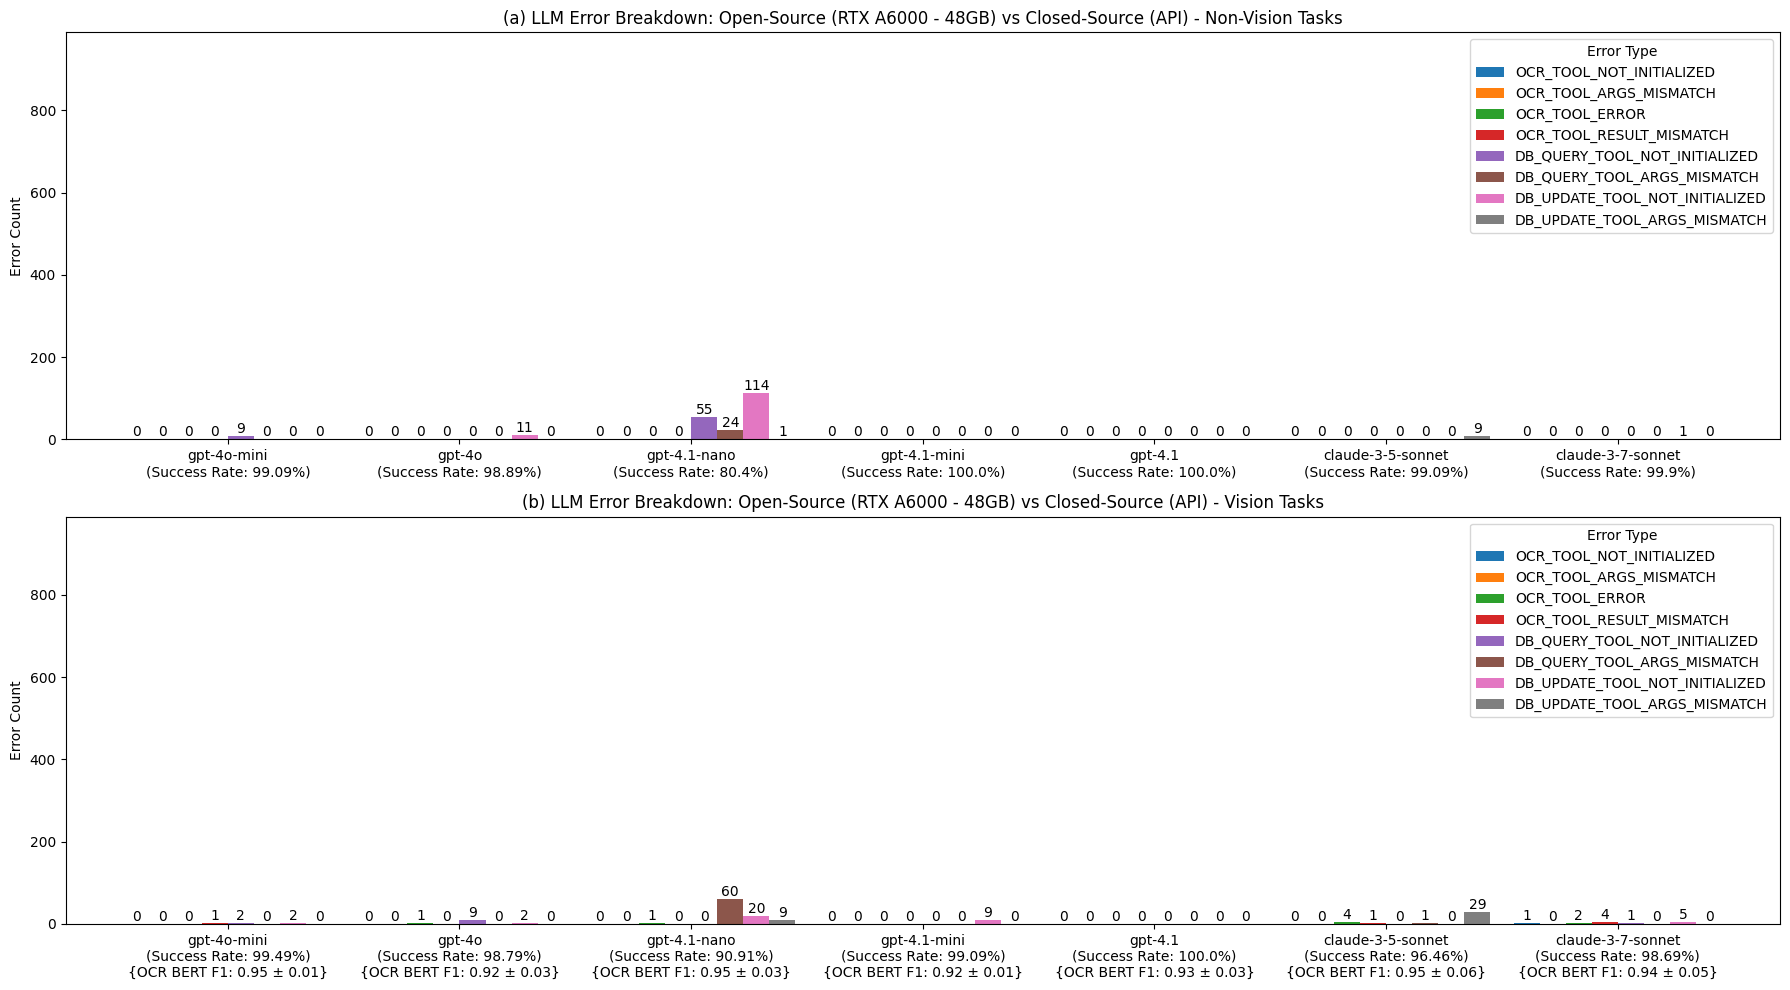

In [17]:
# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10))

df = get_metrics_df(type="non-vision")
filtered_df = df[df["platform"].isin(platforms)].copy()
plot_filtered_df(filtered_df, ylim=990, title="(a) LLM Error Breakdown: Open-Source (RTX A6000 - 48GB) vs Closed-Source (API) - Non-Vision Tasks", ax1=ax1)

df = get_metrics_df(type="vision")
filtered_df = df[df["platform"].isin(platforms)].copy()
plot_filtered_df(filtered_df, ylim=990, title="(b) LLM Error Breakdown: Open-Source (RTX A6000 - 48GB) vs Closed-Source (API) - Vision Tasks", ax1=ax2)

plt.tight_layout()
# plt.xticks(rotation=30)
plt.show()

In [18]:
platforms

['OpenAI', 'RTX A6000 - 48GB', 'Anthropic']

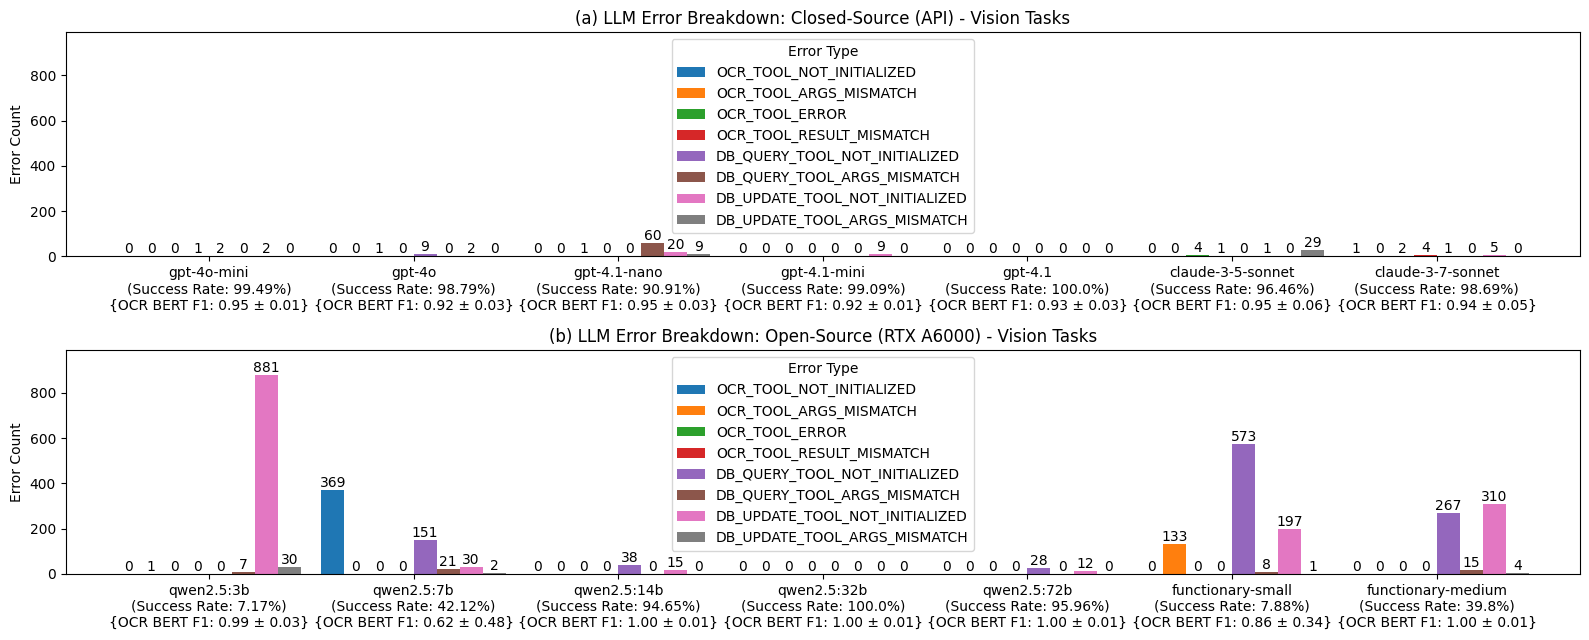

In [19]:
# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6.5))

df = get_metrics_df(type="vision")
platforms = ['OpenAI', 'Anthropic']
filtered_df = df[df["platform"].isin(platforms)].copy()
plot_filtered_df(filtered_df, ylim=990, title="(a) LLM Error Breakdown: Closed-Source (API) - Vision Tasks", ax1=ax1, loc="upper center", bbox_to_anchor=(0.5, 1))

platforms = ['RTX A6000']
filtered_df = df[df["platform"].isin(platforms)].copy()
plot_filtered_df(filtered_df, ylim=990, title="(b) LLM Error Breakdown: Open-Source (RTX A6000) - Vision Tasks", ax1=ax2, loc="upper center", bbox_to_anchor=(0.5, 1))

plt.tight_layout()
# plt.xticks(rotation=30)
plt.show()